In [30]:
import pandas as pd
import numpy as np 

In [31]:
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [32]:
df = pd.read_csv("/Users/apple/Desktop/AI-ML/Datasets/Titanic-Dataset.csv", usecols=['Age', 'Fare', 'Survived'])

In [33]:
df.dropna(inplace=True)

In [34]:
df.shape

(714, 3)

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [38]:
clf = DecisionTreeClassifier()

In [39]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [40]:
accuracy_score(y_test, y_pred)

0.6223776223776224

In [41]:
np.mean(cross_val_score(clf, X, y, cv=10, scoring='accuracy'))

np.float64(0.6274843505477309)

In [42]:
kbin_age = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='kmeans')

In [43]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [44]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)  

In [45]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [46]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [47]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [48]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
682,20.0,3.0,9.2250,0.0,"(19.0, 21.0]","(0.0, 11.241]"
445,4.0,0.0,81.8583,7.0,"(0.42, 6.0]","(72.273, 84.11]"
89,24.0,5.0,8.0500,0.0,"(23.0, 25.0]","(0.0, 11.241]"
749,31.0,8.0,7.7500,0.0,"(30.0, 32.0]","(0.0, 11.241]"
806,39.0,11.0,0.0000,0.0,"(38.0, 42.0]",NaN


In [49]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred = clf.predict(X_test_trf)

In [50]:
accuracy_score(y_test, y_pred)

0.6223776223776224

In [51]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6274647887323944)

In [52]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6330985915492957


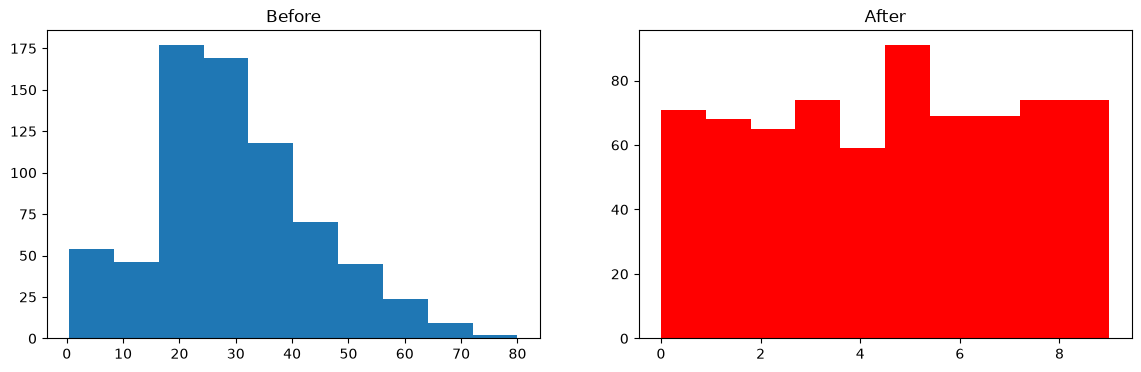

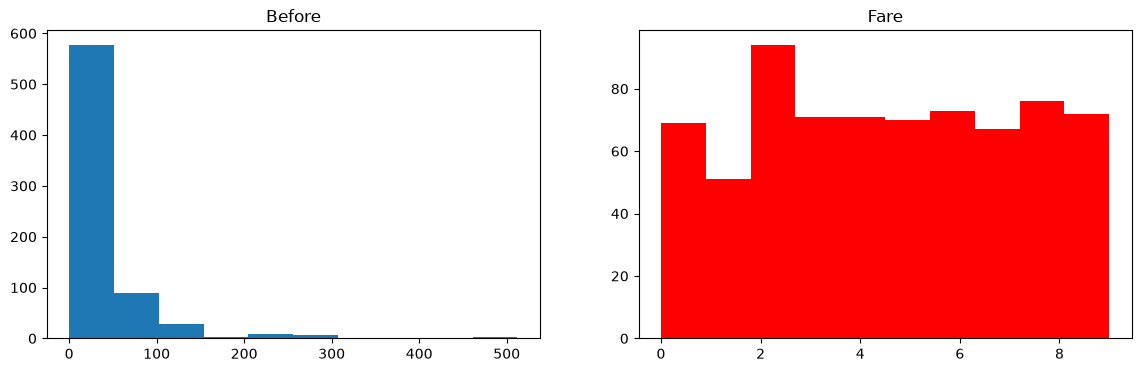

In [53]:
discretize(10, 'quantile')

0.6358763693270735


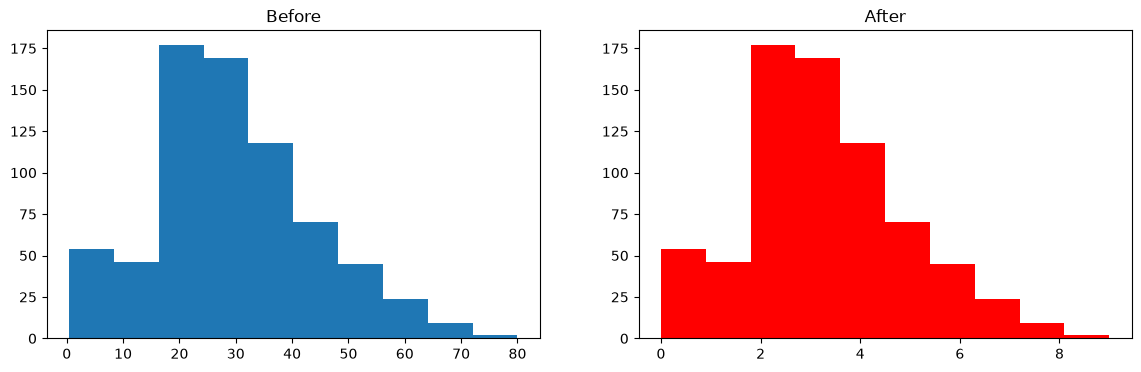

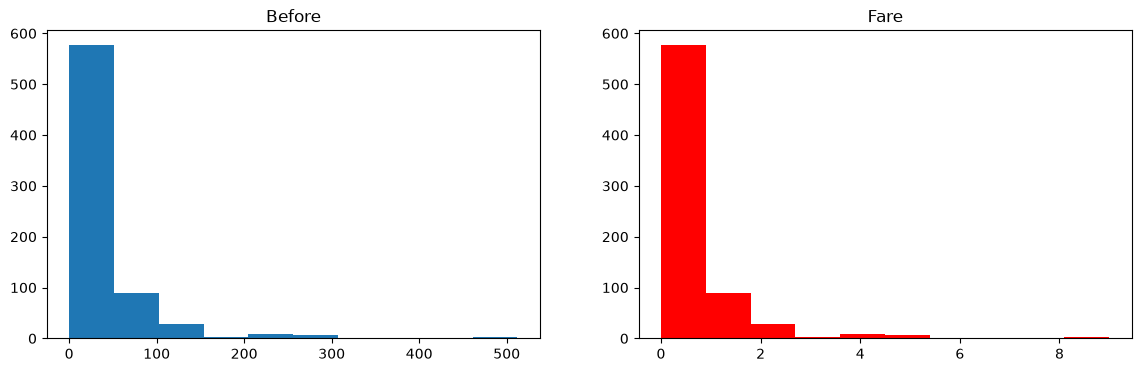

In [54]:
discretize(10, 'uniform')

0.6330985915492958


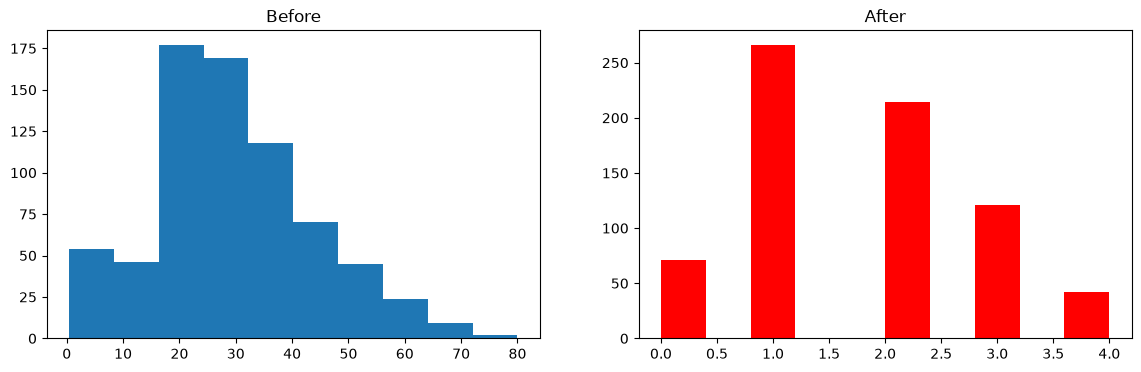

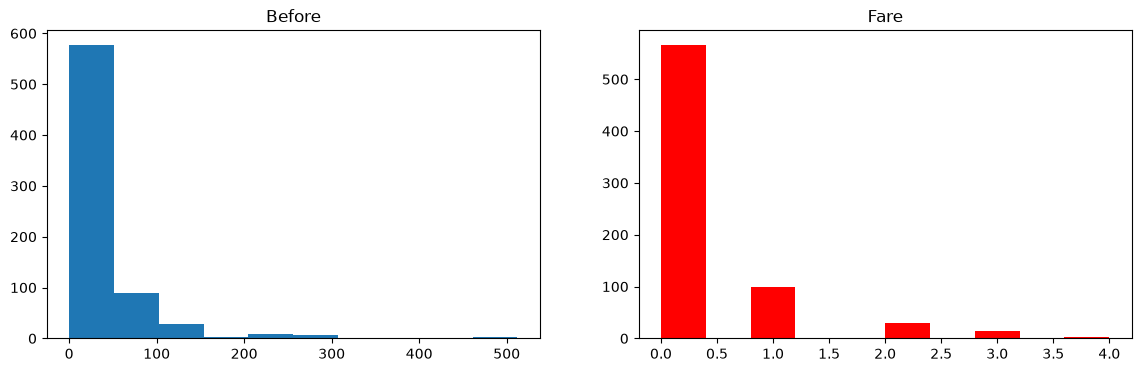

In [55]:
discretize(5, 'kmeans')